In [1]:
import os
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA
from utils import concordance_index

import yaml
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
# root_pth = '/Users/mariana/Documents/projects/Huawei/Results/SA/with_landmark/'
root_pth = '/Users/mariana/Documents/projects/Huawei/Results/deep_TDLambda_00'
config_path = os.path.join(root_pth, 'config.yaml')
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['dataset_kwargs']['data_path'] = '/Users/mariana/Documents/projects/Huawei/SurvanData/mixed_tasks/mixed/H_100/dataset.h5'

In [3]:
model_path = os.path.join(root_pth, 'mixed_tasks/seed_200/model.pt')

In [4]:
model = DeepLambdaSA(config, seed=200)

KeyError: 'type'

In [146]:
params = pickle.load(open(model_path, 'rb'))

In [147]:
model.state = model.state.replace(params=params)

In [148]:
train_gen, test_gen = model.get_train_test()
seqs = test_gen.X
ts = test_gen.ts
cs = test_gen.cs

In [149]:
surv = model.survival_curve(seqs)
bs = model.integrated_brier_score(surv[:,0], ts, cs)
beta = model.state.params['cox_linear_model']['beta']
scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
ci = concordance_index(scores, ts, cs)

In [150]:
bs

Array(0.68171275, dtype=float32)

In [151]:
ci

0.24962291816998583

In [152]:
s_curves = surv[:, 0]

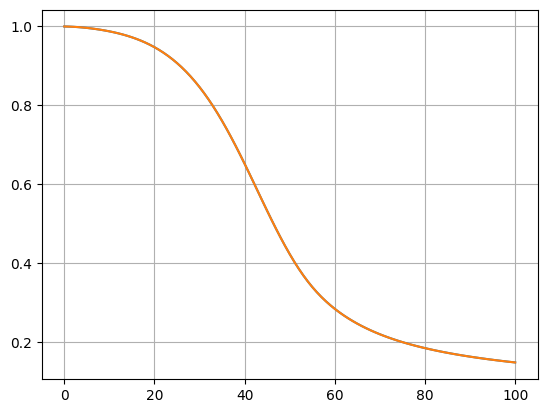

In [153]:
plt.plot(s_curves[cs][10])
plt.plot(s_curves[cs][20])
plt.grid()
plt.show()

In [117]:
s_curves[100]

Array([1.        , 0.99891007, 0.9978099 , 0.9966996 , 0.9955757 ,
       0.9944759 , 0.9934147 , 0.9923495 , 0.9912665 , 0.9901823 ,
       0.9890941 , 0.9879967 , 0.98689914, 0.98580754, 0.9847054 ,
       0.9836232 , 0.98253095, 0.9814423 , 0.98035246, 0.9792695 ,
       0.9781923 , 0.97711504, 0.97604305, 0.9749792 , 0.97393465,
       0.97288984, 0.9718424 , 0.9707989 , 0.9697538 , 0.9687079 ,
       0.96766174, 0.9666264 , 0.9656    , 0.964589  , 0.9635836 ,
       0.96258247, 0.96158236, 0.9605852 , 0.95959127, 0.9585966 ,
       0.9576143 , 0.95663536, 0.9556624 , 0.9546936 , 0.95372856,
       0.9527713 , 0.95182   , 0.95087373, 0.94993246, 0.9489939 ,
       0.94805676, 0.9471192 , 0.94619876, 0.9452878 , 0.9443863 ,
       0.9434825 , 0.9425863 , 0.9417125 , 0.94087094, 0.9400579 ,
       0.93927735, 0.9385252 , 0.93778306, 0.9370491 , 0.9363233 ,
       0.93562126, 0.9349233 , 0.9342312 , 0.933541  , 0.9328615 ,
       0.9321807 , 0.93150264, 0.9308251 , 0.93016624, 0.92951

In [120]:
ts[~cs][10]

97

In [119]:
s_curves[~cs][10]

Array([1.        , 0.99572855, 0.991431  , 0.98710763, 0.9827456 ,
       0.9784905 , 0.9743978 , 0.9703028 , 0.9661527 , 0.96201074,
       0.95786685, 0.9537013 , 0.9495484 , 0.94543254, 0.9412905 ,
       0.9372359 , 0.9331578 , 0.9291054 , 0.9250627 , 0.92105734,
       0.9170873 , 0.9131291 , 0.9092023 , 0.90531784, 0.9015162 ,
       0.89772624, 0.8939377 , 0.8901749 , 0.8864187 , 0.8826724 ,
       0.8789369 , 0.8752502 , 0.8716068 , 0.86802995, 0.86448294,
       0.8609624 , 0.85745573, 0.8539707 , 0.8505068 , 0.84705037,
       0.8436475 , 0.84026706, 0.8369161 , 0.8335901 , 0.83028674,
       0.82701945, 0.8237826 , 0.82057095, 0.8173871 , 0.81422055,
       0.8110683 , 0.8079232 , 0.8048444 , 0.80180633, 0.7988084 ,
       0.79581064, 0.7928475 , 0.7899648 , 0.7871965 , 0.78452885,
       0.7819742 , 0.7795178 , 0.7770996 , 0.77471393, 0.77235955,
       0.7700876 , 0.76783335, 0.76560354, 0.7633842 , 0.76120365,
       0.75902426, 0.7568576 , 0.7546971 , 0.7526009 , 0.75051

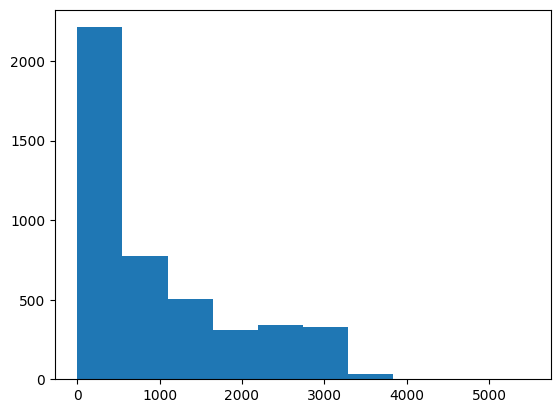

In [75]:
plt.hist(ts)
plt.show()

In [156]:
model.state.params

{'cox_linear_model': {'alpha': Array([-0.6847874 , -0.28364792,  0.07740594,  0.34612623,  0.5489674 ,
          0.7114382 ,  0.849597  ,  0.9734565 ,  1.0892714 ,  1.2008332 ,
          1.3103118 ,  1.4188544 ,  1.5269835 ,  1.6348503 ,  1.7423955 ,
          1.8494598 ,  1.9558464 ,  2.0613582 ,  2.1658127 ,  2.2690625 ,
          2.3710122 ,  2.4716241 ,  2.5709028 ,  2.6688662 ,  2.765522  ,
          2.8608518 ,  2.954802  ,  3.0472786 ,  3.1381621 ,  3.2273176 ,
          3.3145928 ,  3.3998303 ,  3.4828653 ,  3.5635107 ,  3.6415627 ,
          3.7167852 ,  3.788904  ,  3.8576128 ,  3.9225693 ,  3.9834044 ,
          4.0397267 ,  4.09114   ,  4.1372547 ,  4.177701  ,  4.212112  ,
          4.2401104 ,  4.261289  ,  4.2752347 ,  4.281551  ,  4.2798696 ,
          4.269837  ,  4.2511454 ,  4.2237716 ,  4.1883574 ,  4.146407  ,
          4.100037  ,  4.051389  ,  4.002158  ,  3.9534109 ,  3.9056652 ,
          3.8590696 ,  3.8135867 ,  3.7691069 ,  3.725515  ,  3.6827116 ,
         

In [157]:
params

{'cox_linear_model': {'alpha': Array([-0.6847874 , -0.28364792,  0.07740594,  0.34612623,  0.5489674 ,
          0.7114382 ,  0.849597  ,  0.9734565 ,  1.0892714 ,  1.2008332 ,
          1.3103118 ,  1.4188544 ,  1.5269835 ,  1.6348503 ,  1.7423955 ,
          1.8494598 ,  1.9558464 ,  2.0613582 ,  2.1658127 ,  2.2690625 ,
          2.3710122 ,  2.4716241 ,  2.5709028 ,  2.6688662 ,  2.765522  ,
          2.8608518 ,  2.954802  ,  3.0472786 ,  3.1381621 ,  3.2273176 ,
          3.3145928 ,  3.3998303 ,  3.4828653 ,  3.5635107 ,  3.6415627 ,
          3.7167852 ,  3.788904  ,  3.8576128 ,  3.9225693 ,  3.9834044 ,
          4.0397267 ,  4.09114   ,  4.1372547 ,  4.177701  ,  4.212112  ,
          4.2401104 ,  4.261289  ,  4.2752347 ,  4.281551  ,  4.2798696 ,
          4.269837  ,  4.2511454 ,  4.2237716 ,  4.1883574 ,  4.146407  ,
          4.100037  ,  4.051389  ,  4.002158  ,  3.9534109 ,  3.9056652 ,
          3.8590696 ,  3.8135867 ,  3.7691069 ,  3.725515  ,  3.6827116 ,
         